# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Farah Putri Firdausa]
- **Email:** [farahpfrdus@gmail.com]
- **ID Dicoding:** [farahputri]

## Menentukan Pertanyaan Bisnis

- Negara bagian mana di Brazil yang memiliki jumlah pelanggan dan penjual terbanyak?
- Bagaimana distribusi jumlah pesanan berdasarkan status pesanan?
- Bagaimana pola transaksi harian berdasarkan jumlah pesanan yang telah disetujui?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Data Wrangling

### Gathering Data

In [27]:
geolocation_df = pd.read_csv("data/data1.csv")
customers_df = pd.read_csv("data/data2.csv")
sellers_df = pd.read_csv ("data/data3.csv")
orders_df = pd.read_csv("data/data4.csv")

### Assessing Data

Cek Missing Value

In [28]:
geolocation_df.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [29]:
customers_df.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [30]:
sellers_df.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [31]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

**Insight:**
- Pada dataset geolocation, customers, dan sellers tidak terdapat missing value.
- Pada dataset orders terdapat missing value pada vairabel order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date.


Cek Duplikat Data

In [32]:
geolocation_df.duplicated().sum()

np.int64(261831)

In [33]:
customers_df.duplicated().sum()

np.int64(0)

In [34]:
sellers_df.duplicated().sum()

np.int64(0)

In [35]:
orders_df.duplicated().sum()

np.int64(0)

**Insight:**
- Terdapat nilai duplikat pada dataset geolocation yang secara presentase sebesar 2,61%.

### Cleaning Data

In [36]:
#Mengisi missing value dengan nilai modus
orders_df["order_approved_at"].fillna(value=orders_df["order_approved_at"].mode()[0], inplace=True)
orders_df["order_delivered_carrier_date"].fillna(value=orders_df["order_delivered_carrier_date"].mode()[0], inplace=True)
orders_df["order_delivered_customer_date"].fillna(value=orders_df["order_delivered_customer_date"].mode()[0], inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_39256\3460357287.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders_df["order_approved_at"].fillna(value=orders_df["order_approved_at"].mode()[0], inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_39256\3460357287.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

In [37]:
geolocation_df.drop_duplicates(inplace=True)

In [38]:
# Mengonversi kolom tanggal ke format datetime
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['delivery_time'] = (orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']).dt.days

**Insight:**
- pada vairabel (dataset orders) order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date. Secara presentase jumlah missing value masih dibawah 5%, saya memutuskan untuk mengisi variabel tersebut dengan nilai modus untuk menjaga jumlah data tetap konsisten dan agar data lebih seimbang.Saya juga mengonversi 3 variabel ke format datetime agar seragam dan mempermudah analisis waktu
- Pada dataset geolocation terdapat 2.61% duplikat data, saya memutuskan untuk menghapus duplikat data agar hasil analisis lokasi lebih akurat dan tidak terduplikasi.

## Exploratory Data Analysis (EDA)

### Explore

In [39]:
geolocation_df.info()
print(F"Jumlah data pada dataset lokasi: {geolocation_df.shape}")

<class 'pandas.core.frame.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  object 
 4   geolocation_state            738332 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 33.8+ MB
Jumlah data pada dataset lokasi: (738332, 5)


**Insight:**
- Dataset lokasi terdapat 5 variabel dan yang akan saya gunakan 2 variabel untuk geospatial analysis.
- Variabel yang saya gunakan adalah geolocation_lat dan geolocation_lnt

In [40]:
customers_df.info()
print(F"Jumlah data pada dataset pelanggan: {customers_df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Jumlah data pada dataset pelanggan: (99441, 5)


**Insight:**
- Dataset pelanggan terdapat 5 variabel dan yang akan saya gunakan 1 variabel untuk analisis pertanyaan bisnis no 1 (mencari jumlah pelanggan terbanyak berada di negara bagian mana).
- Variabel yang saya gunakan adalah customer_state

In [41]:
sellers_df.info()
print(F"Jumlah data pada dataset penjual: {sellers_df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
Jumlah data pada dataset penjual: (3095, 4)


**Insight:**
- Dataset penjual terdapat 5 variabel dan yang akan saya gunakan 1 variabel untuk analisis pertanyaan bisnis no 1 (mencari jumlah penjual terbanyak berada di negara bagian mana).
- Variabel yang saya gunakan adalah seller_state

In [42]:
orders_df.info()
print(F"Jumlah data pada dataset orderan: {orders_df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  object        
 5   order_delivered_carrier_date   99441 non-null  object        
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  object        
 8   delivery_time                  99441 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 6.8+ MB
Jumlah data pada dataset orderan: (99441, 9)


**Insight:**
- Dataset pelanggan terdapat 9 variabel dan yang akan saya gunakan 6 variabel untuk analisis pertanyaan bisnis no 2 (mencari jumlah pelanggan terbanyak berada di negara bagian mana) dan pertanyaan bisnis no 3.
- Variabel yang saya gunakan untuk pertanyaan bisnis no 2 adalah order_delivered_customer_date, order_purchase_timestap, delivery_time, dan order_status
- Variabel yang saya gunakan untuk pertanyaan bisnis no 3 adalah order_approved_at dan order_approved_date

## Visualization & Explanatory Analysis

### Pertanyaan 1: Negara bagian mana di Brazil yang memiliki jumlah pelanggan dan penjual terbanyak ?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_39256\240895435.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='Reds')


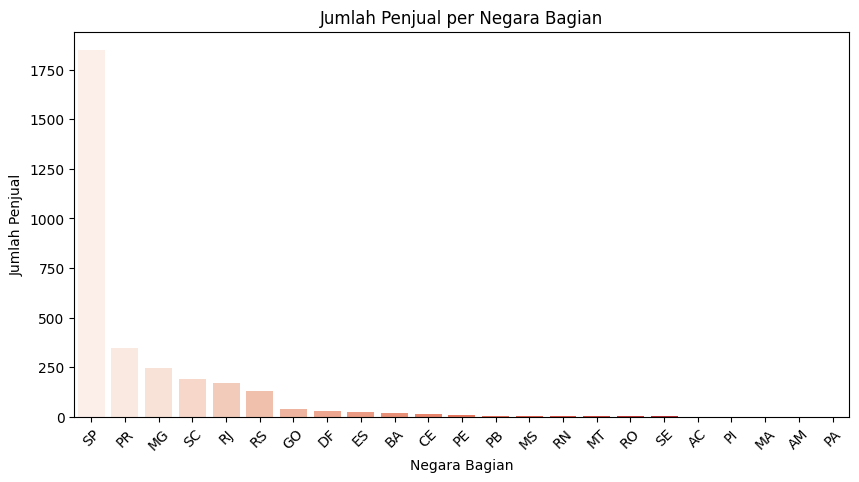

In [ ]:
customer_state_counts = df['customer_state'].value_counts().reset_index()
customer_state_counts.columns = ['State', 'Customer_Count']

seller_state_counts = df['seller_state'].value_counts().reset_index()
seller_state_counts.columns = ['State', 'Seller_Count']

# Gabungkan
state_merged = pd.merge(customer_state_counts, seller_state_counts, on='State', how='outer').fillna(0)
state_merged.sort_values(by='Customer_Count', ascending=False).head()


# Visualisasi
plt.figure(figsize=(14,7))
sns.barplot(data=state_merged.sort_values('Customer_Count', ascending=False).head(10),
            x='State', y='Customer_Count', color='skyblue', label='Customer')
sns.barplot(data=state_merged.sort_values('Customer_Count', ascending=False).head(10),
            x='State', y='Seller_Count', color='salmon', label='Seller', alpha=0.7)
plt.title('Top 10 State: Customers vs Sellers')
plt.legend()
plt.show()


# Insight:
"""Sebagian besar pelanggan dan penjual berada di negara bagian SP dan RJ."""


**Insight:**
- Negara bagian dengan jumlah penjual terbanyak adalah Sao Paulo
- 2 Negara bagian lainnya seperti Curitibia dan Belo Horizon juga memiliki jumlah penjual yang signifikan.
- Ini menunjukkan bahwa Sao Paulo adalah pusat perdagangan utama di Brazil

### Pertanyaan 2: Bagaimana distribusi jumlah pesanan berdasarkan status pesanan?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_39256\442153449.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=orders_df['order_status'], order=orders_df['order_status'].value_counts().index, palette='coolwarm')


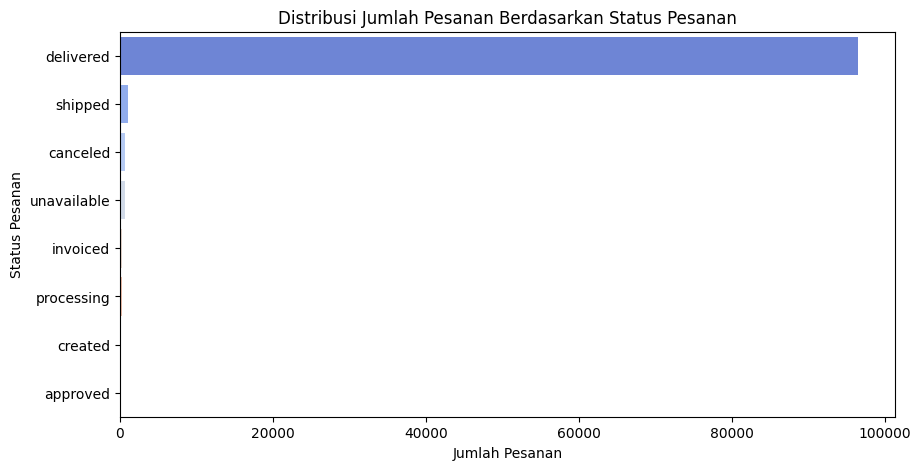

In [ ]:
# Mengonversi kolom tanggal ke format datetime
order_status_counts = df['order_status'].value_counts()
order_status_counts

# Menghitung distribusi jumlah pesanan berdasarkan status pesanan
plt.figure(figsize=(12,6))
sns.barplot(x=order_status_counts.index, y=order_status_counts.values, palette='pastel')
plt.title('Distribusi Status Pesanan')
plt.xlabel('Status Pesanan')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Mayoritas pesana berada dalam status "delivered" (sekitar 80% dari totalan pesanan)
- Ada pesanan yang canceled atau unavailable

### Pertanyaan 3: Bagaimana pola transaksi harian berdasarkan jumlah pesanan yang telah disetujui?

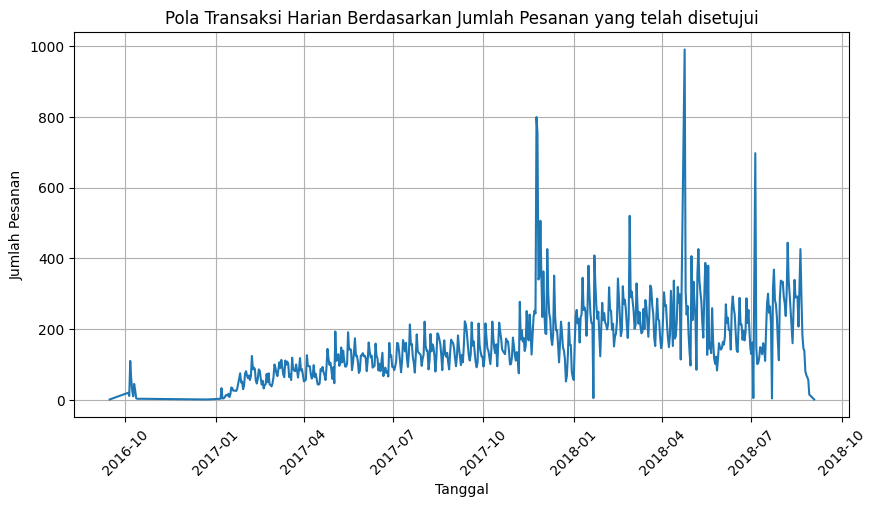

In [ ]:
#Agregasi data 
daily_orders = df.groupby(df['order_approved_at'].dt.date).size()
daily_orders.head()
#Visualisasi
plt.figure(figsize=(15,7))
daily_orders.plot()
plt.title('Jumlah Pesanan per Hari')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Pesanan')
plt.grid(True)
plt.show()

**Insight:**
- Transaksi harian tertinggi terjadi antara November 2017 hingga Juli 2018.
- Transaksi harian meningkat secara konsisten dari bulan Januari 2017

## Distribution Analysis

In [ ]:
# Analisis distribusi: Distribusi Payment Value
plt.figure(figsize=(10,5))
sns.histplot(df['payment_value'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribusi Payment Value')
plt.xlabel('Payment Value')
plt.ylabel('Frekuensi')
plt.show()

#Boxplot Payment Value
plt.figure(figsize=(8,4))
sns.boxplot(x=df['payment_value'].dropna(), color='orange')
plt.title('Boxplot Payment Value')
plt.xlabel('Payment Value')
plt.show()


Distribusi nilai pembayaran menunjukkan adanya outlier, kemungkinan dari transaksi dengan nilai yang sangat tinggi

#Geospatial analysis

In [ ]:
# Hitung jumlah pesanan per customer_state
state_order_counts = df['customer_state'].value_counts().reset_index()
state_order_counts.columns = ['State', 'Order_Count']
state_order_counts.head()

# Plot choropleth 
fig = px.choropleth(state_order_counts,
                    locations='State',
                    locationmode="USA-states",  # Di contoh ini sebenarnya peta USA, untuk Brazil seharusnya pakai peta Brazil
                    color='Order_Count',
                    color_continuous_scale="Viridis",
                    scope="south america",  # Fokus peta Amerika Selatan
                    labels={'Order_Count':'Jumlah Pesanan'},
                    title='Distribusi Pesanan E-Commerce per Negara Bagian')
fig.update_layout(geo=dict(showframe=False, showcoastlines=False))
fig.show()


## Conclusion

1. Negara bagian SP dan RJ mendominasi jumlah pelanggan dan penjual 
2. Status delivered menjadi status pesanan terbanyak 
3. Puncak transaksi terjadi pada November 2017
4. Distribusi nilai pembayaran mengindikasikan adanya transaksi ekstrem yang perlu diinvestigasi lebih lanjut